# advection_diffusion.ipynb

#### Robert Peal and Patrick Schmitt March 2026

- An implementation of the advection diffusion equation for use in the UIBK MSc extension programme on mountain regions, lecture 3b: Modelling the atmosphere in complex terrain

#### Tracers in the atmosphere

- The atmosphere can sometimes carry small particles, like dust, water vapour, or smoke. These small particles are often known as tracers
- They can have significant impacts on air quality and so it is important to understand, when they are released, how they will affect the surroundings
    - see for example, the Nordkette fire (https://www.krone.at/3999265)
- This knowledge can inform us for example, if certain areas should be evacuated if the concentrations will become dangerously high

- The evolution of the concentration of these particles can be understood using the "advection-diffusion equation", which describes how the concentration of particulate matter in the atmosphere will change over time

#### The advection-diffusion equation in 2D

Solves:

$$
\frac{\partial C}{ \partial t} + u \frac{\partial C}{ \partial x} + v \frac{\partial C}{ \partial y} = K \left(\frac{\partial ^2 C}{ \partial x^2} + \frac{\partial ^2 C}{ \partial y^2}\right )
$$

where:

- $C(x, y, t)$ = tracer concentration (e.g. a pollutant)
- $u$, $v$ = wind components (m/s)
- $K$ = diffusivity parameter (m²/s), can be spatially varying


#### Breaking down the equation:

$$
\frac{\partial C}{ \partial t}
$$

is the time varying part. "How the value of C at every location in the model changes with time".

$$
u \frac{\partial C}{ \partial x} + v \frac{\partial C}{ \partial y}
$$

is the advection part - how the background wind field moves the particles through the domain

$$
K \left(\frac{\partial ^2 C}{ \partial x^2} + \frac{\partial ^2 C}{ \partial y^2}\right )
$$

is the diffusion part, how the particles spread out through the domain. Particles favourably move from areas of high concentration to low concentration.

#### Implementation notes

Numerical scheme:
- Advection:  first-order upwind (stable for CFL <= 1)
- Diffusion:  central differences (FTCS, stable for d <= 0.5)
- Time:       explicit forward Euler

This code is intentionally simple and readable.
Students are encouraged to experiment with the parameters below.

Author: prepared for "Modelling in Complex Terrain" lecture series by Robert Peal and Patrick Schmitt, with help from Claude

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

## 1. Grid and Time setup

In [2]:
# Here we define the spatial and temporal resolution, and how long we want to simulate

Lx = 10_000.0        # domain width  (m)
Ly = 10_000.0        # domain height (m)
nx = 100             # grid points in x
ny = 100             # grid points in y
dx = Lx / nx
dy = Ly / ny

x = np.linspace(0.5 * dx, Lx - 0.5 * dx, nx)   # cell centres
y = np.linspace(0.5 * dy, Ly - 0.5 * dy, ny)
X, Y = np.meshgrid(x, y)                         # shape (ny, nx)

dt        = 30.0       # time step (s)
n_steps   = 1200        # number of steps to run
save_every = 10        # save a snapshot every N steps

## 2. Wind Field (experiment here!)

In [3]:
# Here we define differnt wind fields to play with, you can add your own here
# Supported options are 'uniform', 'valley', 'circular'

def get_wind_field(wind_field):
    if wind_field == 'uniform':
        # Option A: uniform wind
        u = 0.25 * np.ones((ny, nx))    # m/s  eastward
        v = 0.0 * np.ones((ny, nx))    # m/s  northward
    
    elif wind_field == 'valley':
        # Option B: simple valley channelling — uncomment to try
        u = 1. * np.sin(np.pi * Y / Ly)
        v = np.zeros((ny, nx))
    
    elif wind_field == 'circular':
        # Option C: a circular/vortex wind field — uncomment to try
        cx, cy = Lx / 2, Ly / 2
        u =  (Y - cy) / (Ly / 2) * 1
        v = -(X - cx) / (Lx / 2) * 1
    
    else:
        raise NotImplementedError(f"{wind_field} not understood, options are: "
                                  "'uniform', 'valley', 'circular'")

    return u, v

wind_field = 'uniform'
u, v = get_wind_field(wind_field=wind_field)

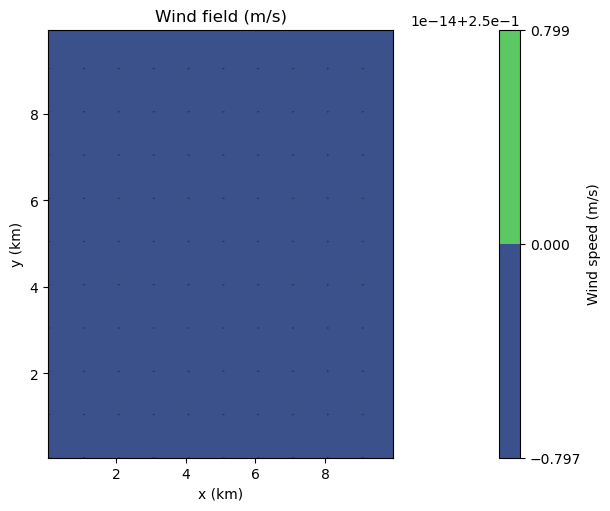

In [4]:
# Function for plotting the wind field

def plot_wind_field(u, v, wind_field, save_plots=True):
    fig,ax=plt.subplots(figsize=(6, 5), constrained_layout=True)
    im=ax.contourf(X / 1000, Y / 1000, np.sqrt(u**2 + v**2), cmap='viridis')
    ax.quiver(X[::10, ::10] / 1000, Y[::10, ::10] / 1000,
                   u[::10, ::10], v[::10, ::10],
                   scale=30, width=0.003, alpha=0.4, color='black')
    plt.colorbar(im, label="Wind speed (m/s)", alpha=1)
    ax.set_xlabel("x (km)")
    ax.set_ylabel("y (km)")
    ax.set_title("Wind field (m/s)")

    if save_plots:
        filename = f"wind_field_{wind_field}.png"
        plt.savefig(filename, dpi=150)
        print(f"Saved: {filename}")

    plt.show()

plot_wind_field(u=u, v=v, wind_field=wind_field, save_plots=False)

## 3. Diffusivity (experiment here!)

In [5]:
# Here we define differnt wind fields to play with, you can add your own here
# Supported options are 'uniform', 'half-half', 'turbulent'

def get_diffusivity(diffusivity, u, v):
    if diffusivity == 'uniform':
        # Option A: uniform K
        K = 10.0 * np.ones((ny, nx))   # m²/s  (representative of stable valley BL)
        
    elif diffusivity == 'half-half':
        # Option B: stronger mixing in the upper half of domain
        K = np.where(Y > Ly / 2, 50.0, 5.0)

    elif diffusivity == 'turbulent':
        # Option C: K proportional to wind speed (crude turbulence parametrisation)
        wind_speed = np.sqrt(u**2 + v**2)
        K = 0.1 * wind_speed * dx      # mixing-length style

    else:
        raise NotImplementedError(f"{diffusivity} not understood, options are: "
                                  "'uniform', 'half-half', 'turbulent'")

    return K

diffusivity = 'turbulent'
K = get_diffusivity(diffusivity=diffusivity, u=u, v=v)

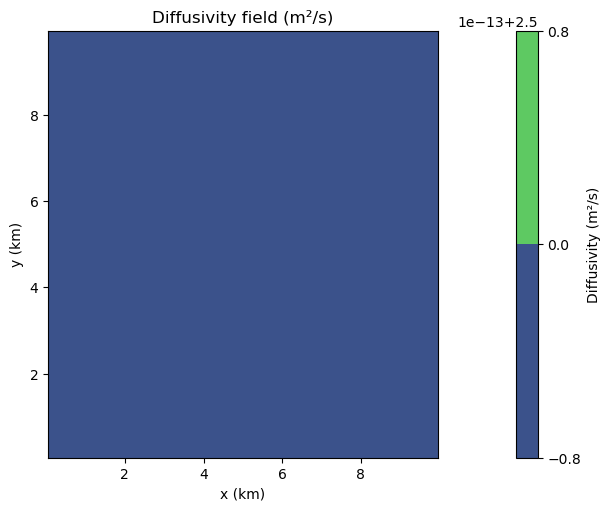

In [6]:
# Function for plotting the diffusivity field

def plot_diffusivity(K, diffusivity, wind_field, save_plots=True):
    fig,ax=plt.subplots(figsize=(6, 5), constrained_layout=True)
    im=ax.contourf(X / 1000, Y / 1000, K, cmap='viridis')
    plt.colorbar(im,label="Diffusivity (m²/s)",alpha=1)
    ax.set_xlabel("x (km)")
    ax.set_ylabel("y (km)")
    ax.set_title("Diffusivity field (m²/s)")

    if save_plots:
        filename = f"diffusivity_field_{diffusivity}_wind_{wind_field}.png"
        plt.savefig(filename, dpi=150)
        print(f"Saved: {filename}")

    plt.show()

plot_diffusivity(K=K, diffusivity=diffusivity, wind_field=wind_field, save_plots=False)

## 4. Stability check

In [7]:
# here we check for numeric stability

def stability_check(u, v, K):
    CFL_x = np.max(np.abs(u)) * dt / dx
    CFL_y = np.max(np.abs(v)) * dt / dy
    d_x   = np.max(K) * dt / dx**2
    d_y   = np.max(K) * dt / dy**2
    
    print("=== Stability diagnostics ===")
    print(f"  Courant number (x): {CFL_x:.3f}  {'OK' if CFL_x <= 1 else '*** UNSTABLE — reduce dt or increase dx ***'}")
    print(f"  Courant number (y): {CFL_y:.3f}  {'OK' if CFL_y <= 1 else '*** UNSTABLE — reduce dt or increase dx ***'}")
    print(f"  Diffusion number (x): {d_x:.4f}  {'OK' if d_x <= 0.5 else '*** UNSTABLE — reduce dt or K ***'}")
    print(f"  Diffusion number (y): {d_y:.4f}  {'OK' if d_y <= 0.5 else '*** UNSTABLE — reduce dt or K ***'}")
    print()
    
    if CFL_x > 1 or CFL_y > 1 or d_x > 0.5 or d_y > 0.5:
        raise ValueError("Unstable configuration — adjust parameters before running.")

stability_check(u=u, v=v, K=K)

=== Stability diagnostics ===
  Courant number (x): 0.075  OK
  Courant number (y): 0.000  OK
  Diffusion number (x): 0.0075  OK
  Diffusion number (y): 0.0075  OK



## 5. Source term (experiment here!)

In [8]:
# Here we define our source

def get_source(source_type):
    if source_type == 'gaussian':
        # Option A: Gaussian pulse — a single, one-off release of tracer.
        # The plume is injected as the initial condition and then
        # freely advected and diffused.  No further tracer is added.
        
        x0    = 0.25 * Lx   # source location x (m)
        y0    = 0.5 * Ly   # source location y (m)
        sigma = 400.0        # initial plume width (m)
        
        C = np.exp(-((X - x0)**2 + (Y - y0)**2) / (2 * sigma**2))
        
        # Source mask is empty for a pure pulse (all emission was at t=0)
        source_mask = np.zeros((ny, nx))
    
    elif source_type == 'fire':
        # Option B: Constant source — simulates a sustained emitter such as a
        # wildfire.  A fixed amount of tracer (source_rate, in
        # concentration per second) is added to the source region at
        # every time step, continuously throughout the simulation.
        
        # Fire location and size
        x0_fire    = 0.25 * Lx   # fire centre x (m)
        y0_fire    = 0.5 * Ly   # fire centre y (m)
        fire_radius = 400.0       # radius of the burning area (m)
        source_rate = 0.5         # emission rate (concentration/s)
        
        # Boolean mask: True inside the fire perimeter
        fire_mask = (X - x0_fire)**2 + (Y - y0_fire)**2 <= fire_radius**2
        
        # Build the continuous source field (concentration/s at each cell)
        source_mask = source_rate * fire_mask.astype(float)
        
        # Start with zero concentration — tracer builds up from the fire
        C = source_mask
    else:
        raise NotImplementedError(f"{source_type} not understood, options are: "
                                  "'gaussian', 'fire'")

    return C, source_mask

source_type = 'fire'
C, source_mask = get_source(source_type=source_type)

## 6. Boundary condition

In [9]:
# here we define what happens at the boundaries of our domain

# Choose one of the two options below:
#
#   'dirichlet' : Absorbing boundaries — concentration is set to zero
#                 at the edges.  Tracer that reaches the boundary is
#                 removed from the domain (no re-entry).
#
#   'periodic'  : Periodic (wrap-around) boundaries — tracer that leaves
#                 one edge reappears on the opposite edge.  Mass is
#                 conserved; the domain acts like a torus.
#

def get_boundary_condition(boundary_condition):
    if boundary_condition == 'dirichlet':
        # Pad C with a border of zeros on all four sides (Dirichlet BC: C=0).
        # This means any flux or gradient that reaches the domain edge sees
        # zero concentration outside — tracer is absorbed at the boundary.
        def pad(C):
            return np.pad(C, pad_width=1, mode='constant', constant_values=0.0)
        
    elif boundary_condition == 'periodic':
        # Pad C by wrapping values from the opposite edge (periodic BC).
        # Tracer that exits through one side re-enters through the opposite
        # side — the domain is topologically a torus.
        def pad(C):
            return np.pad(C, pad_width=1, mode='wrap')

    else:
        raise NotImplementedError(f"{boundary_condition} not understood, options are: "
                                  "'dirichlet', 'periodic'")

    return pad

boundary_condition = 'dirichlet'

## 7. Time Integration

In [10]:
def step(C, u, v, K, dx, dy, dt, source_mask,
         boundary_condition='dirichlet'):
    """
    Advance concentration C by one time step dt.

    Advection:  first-order upwind scheme (conservative flux form)
    Diffusion:  second-order centred (FTCS)
    Source:     optional continuous emission field (source_mask, conc/s).
                Pass np.zeros((ny, nx)) for no continuous source.
    Boundaries: controlled by the `boundary_condition` argument:
                  'dirichlet' — C=0 at all edges (tracer absorbed at boundary)
                  'periodic'  — wrap-around; tracer exits one side and
                                re-enters from the opposite side
    """
    # Choose the padding function based on the selected boundary condition
    pad = get_boundary_condition(boundary_condition=boundary_condition)

    # Pad arrays to enforce the chosen boundary condition
    Cp = pad(C)   # shape (ny+2, nx+2)
    up = pad(u)
    vp = pad(v)
    Kp = pad(K)

    # Interior slice indices (the original domain)
    i    = np.s_[1:-1, 1:-1]   # centre
    im1x = np.s_[1:-1, :-2]    # one step left  (i-1 in x)
    ip1x = np.s_[1:-1, 2:]     # one step right (i+1 in x)
    im1y = np.s_[:-2, 1:-1]    # one step down  (j-1 in y)
    ip1y = np.s_[2:, 1:-1]     # one step up    (j+1 in y)

    # --- Advection (upwind, conservative flux form) ---
    # For each cell face, compute the flux F = u * C_upwind.
    # The wind velocity at the face determines which cell is 'upwind'.
    # Net advection = (F_right_face - F_left_face) / dx

    # x-direction: right face (i+1/2) — wind velocity is up[ip1x]
    u_right = up[ip1x]                            # wind at right face
    F_x_right = np.where(u_right >= 0,
                          u_right * Cp[i],         # wind blows right: upwind is centre
                          u_right * Cp[ip1x])      # wind blows left:  upwind is right

    # x-direction: left face (i-1/2) — wind velocity is up[im1x+1] = up[i]
    # NOTE: the face between cell i-1 and cell i has the wind value at that
    # face.  A simple choice is to take the average, but for a uniform or
    # cell-centred wind field the face value equals up[i] for the left face
    # seen from cell i, which is what we use here (matches the right-face
    # convention: face i+1/2 uses up[ip1x], so face i-1/2 uses up[i]).
    u_left = up[i]                                 # wind at left face
    F_x_left  = np.where(u_left >= 0,
                          u_left * Cp[im1x],        # wind blows right: upwind is left
                          u_left * Cp[i])           # wind blows left:  upwind is centre

    adv_x = (F_x_right - F_x_left) / dx

    # y-direction: top face (j+1/2)
    v_top = vp[ip1y]
    F_y_top  = np.where(v_top >= 0,
                         v_top * Cp[i],             # wind blows up: upwind is centre
                         v_top * Cp[ip1y])          # wind blows down: upwind is top

    # y-direction: bottom face (j-1/2)
    v_bot = vp[i]
    F_y_bot  = np.where(v_bot >= 0,
                         v_bot * Cp[im1y],          # wind blows up: upwind is bottom
                         v_bot * Cp[i])             # wind blows down: upwind is centre

    adv_y = (F_y_top - F_y_bot) / dy

    # --- Diffusion (conservative flux form for spatially varying K) ---
    # The correct discretisation of  d/dx(K dC/dx) + d/dy(K dC/dy)  is
    # the flux form, which is conservative by construction:
    #
    #   d/dx(K dC/dx) ≈ (K_{i+1/2}*(C_{i+1}-C_i) - K_{i-1/2}*(C_i-C_{i-1})) / dx²
    #
    # K at each face is the arithmetic mean of the two neighbouring cell values.
    # This guarantees that the flux leaving one cell equals the flux entering
    # the next, so diffusion alone cannot create or destroy total mass.
    #
    # The simpler formula  K_i * (C_{i+1} - 2*C_i + C_{i-1}) / dx²  is only
    # correct when K is spatially uniform.  With a varying K (e.g. Option C)
    # it is non-conservative and will spuriously create or destroy tracer mass.

    # K at cell faces (arithmetic mean of neighbouring cell values)
    K_x_right = 0.5 * (Kp[i] + Kp[ip1x])   # K at right face  (i+1/2)
    K_x_left  = 0.5 * (Kp[i] + Kp[im1x])   # K at left face   (i-1/2)
    K_y_top   = 0.5 * (Kp[i] + Kp[ip1y])   # K at top face    (j+1/2)
    K_y_bot   = 0.5 * (Kp[i] + Kp[im1y])   # K at bottom face (j-1/2)

    # Diffusive fluxes at each face
    F_diff_x_right = K_x_right * (Cp[ip1x] - Cp[i])   / dx
    F_diff_x_left  = K_x_left  * (Cp[i]    - Cp[im1x]) / dx
    F_diff_y_top   = K_y_top   * (Cp[ip1y] - Cp[i])   / dy
    F_diff_y_bot   = K_y_bot   * (Cp[i]    - Cp[im1y]) / dy

    # Net diffusion = divergence of diffusive flux
    diff = (F_diff_x_right - F_diff_x_left) / dx \
         + (F_diff_y_top   - F_diff_y_bot)  / dy


    # --- Continuous source injection (e.g. wildfire) ---
    # source_mask has units of concentration/s; multiply by dt to get
    # the amount added in this time step.
    C_new = C + dt * (-adv_x - adv_y + diff + source_mask)

    # Clip to avoid tiny negative values from numerical diffusion
    C_new = np.clip(C_new, 0.0, None)

    # --- Dirichlet BC: enforce C=0 on the boundary strip of the OUTPUT ---
    if boundary_condition == 'dirichlet':
        C_new[:1,  :] = 0.0   # bottom two rows
        C_new[-1:, :] = 0.0   # top two rows
        C_new[:,  :1] = 0.0   # left two columns
        C_new[:, -1:] = 0.0   # right two columns

    return C_new


## 8. Visualisations

In [11]:
# Snapshot plot with static observers
def snapshot_plot_with_observers(times, snapshots, u, v,
                                 filesuffix='', observers=None,
                                 save_plot=True):
    # --- Observers ---
    # Define any number of static observers as (x_m, y_m, label) tuples.
    # Each observer gets its own colour automatically.
    if observers is None:
        observers = [
            (5000, 8000, "Observer A"),
            (7000, 5000, "Observer B"),
            (3000, 3000, "Observer C"),
        ]
    
    # Convert physical positions to grid indices and assign colours
    obs_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    observer_data = []
    for k, (xo, yo, label) in enumerate(observers):
        xi = int(xo / dx)
        yi = int(yo / dy)
        color = obs_colors[k % len(obs_colors)]
        conc  = [snap[yi, xi] for snap in snapshots]   # note: snap[row=y, col=x]
        observer_data.append(dict(x_m=xo, y_m=yo, label=label,
                                   color=color, conc=conc))
    
    fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)

    # show snapshots for three timesteps: first, middle, last snapshot
    axs_snapshots = [axes[0, 0], axes[0, 1], axes[1, 0]]
    indices = [0, len(snapshots) // 2, -1]
    
    for ax, idx in zip(axs_snapshots, indices):
        vmax = np.max(snapshots[idx]) or 1.0
        im = ax.pcolormesh(x / 1000, y / 1000, snapshots[idx],
                           cmap='YlOrRd', vmin=0, vmax=vmax, shading='auto')
        ax.quiver(X[::10, ::10] / 1000, Y[::10, ::10] / 1000,
                  u[::10, ::10], v[::10, ::10],
                  scale=20, width=0.003, alpha=0.4, color='steelblue')
        # Plot each observer with its own colour
        for obs in observer_data:
            ax.plot(obs["x_m"] / 1000, obs["y_m"] / 1000,
                    'x', color=obs["color"], markersize=8, markeredgewidth=2,
                    label=obs["label"])
        ax.legend(fontsize=7, loc='upper right')
        ax.set_title(f"t = {times[idx]/60:.1f} min")
        ax.set_xlabel("x (km)")
        ax.set_ylabel("y (km)")
        plt.colorbar(im, ax=ax, label="C (normalised)")
    
    # plot concentrations of observers
    ax_obs = axes[1, 1]
    for obs in observer_data:
        ax_obs.plot(np.array(times) / 60, obs["conc"],
                    color=obs["color"], label=obs["label"])
    ax_obs.set_xlabel("Time (min)")
    ax_obs.set_ylabel("C at observer")
    ax_obs.set_title("Observer time series")
    ax_obs.legend(fontsize=8)
    
    fig.suptitle(f"2D Advection-Diffusion: tracer evolution\n{filesuffix}", fontsize=13)

    if save_plot:
        filename = f"snapshots{filesuffix}.png"
        plt.savefig(filename, dpi=150)
        print(f"Saved: {filename}")

    plt.show()

In [12]:
# --- Animation ---
def create_animation(times, snapshots, u, v, filesuffix=''):
    fig_anim, ax_anim = plt.subplots(figsize=(6, 5), constrained_layout=True)
    vmax = np.max(snapshots)
    im_anim = ax_anim.pcolormesh(x / 1000, y / 1000, snapshots[0],
                                  cmap='YlOrRd', vmin=0,
                                  vmax=vmax,
                                 shading='auto')
    ax_anim.quiver(X[::10, ::10] / 1000, Y[::10, ::10] / 1000,
                   u[::10, ::10], v[::10, ::10],
                   scale=20, width=0.003, alpha=0.4, color='steelblue')
    plt.colorbar(im_anim, ax=ax_anim, label="C (normalised)")
    ax_anim.set_xlabel("x (km)")
    ax_anim.set_ylabel("y (km)")
    title_anim = ax_anim.set_title(f"t = 0.0 min\n{filesuffix}")


    def update(frame):
        data = snapshots[frame]
        vmax = np.max(snapshots)
        im_anim.set_array(data.ravel())
        im_anim.set_clim(vmin=0, vmax=vmax)
        title_anim.set_text(f"t = {times[frame]/60:.1f} min\n{filesuffix}")
        return im_anim, title_anim


    ani = animation.FuncAnimation(fig_anim, update, frames=len(snapshots),
                                   interval=80, blit=True)
    filename = f"animation{filesuffix}.gif"
    ani.save(filename,
             writer='pillow', fps=12)
    print(f"Saved: {filename}")
    plt.close()

## 9. Function to run the model

In [13]:
def run_simulation(wind_field, diffusivity, source_type, boundary_condition,
                   show_plots=True, save_plots=True, save_animation=False,
                   observers=None,
                  ):

    # define wind field
    u, v = get_wind_field(wind_field=wind_field)
    if show_plots:
        plot_wind_field(u=u, v=v, wind_field=wind_field,
                        save_plots=save_plots)

    # define diffusivity
    K = get_diffusivity(diffusivity=diffusivity, u=u, v=v)
    if show_plots:
        plot_diffusivity(K=K, diffusivity=diffusivity, wind_field=wind_field,
                         save_plots=save_plots)

    # numeric stability test
    stability_check(u=u, v=v, K=K)

    # define the source
    C, source_mask = get_source(source_type=source_type)

    # do time stepping starting with initial condition
    # in the for loop we always go one time step further
    snapshots = [C.copy()]
    times     = [0.0]
    
    for n in range(n_steps):
        C = step(C, u, v, K, dx, dy, dt, source_mask, boundary_condition)
        if (n + 1) % save_every == 0:
            snapshots.append(C.copy())
            times.append((n + 1) * dt)
    
    print(f"Integration complete: {n_steps} steps, {n_steps * dt / 60:.1f} minutes simulated.")

    if show_plots:
        filesuffix = (f"_wind_{wind_field}_diffu_{diffusivity}_source_{source_type}"
                      f"_bc_{boundary_condition}")
        snapshot_plot_with_observers(times, snapshots, u, v,
                                     filesuffix=filesuffix, observers=observers,
                                     save_plot=save_plots)

    if save_animation:
        create_animation(times, snapshots, u, v, filesuffix=filesuffix)

    print("DONE")

## 10. Experiment

Saved: wind_field_uniform.png


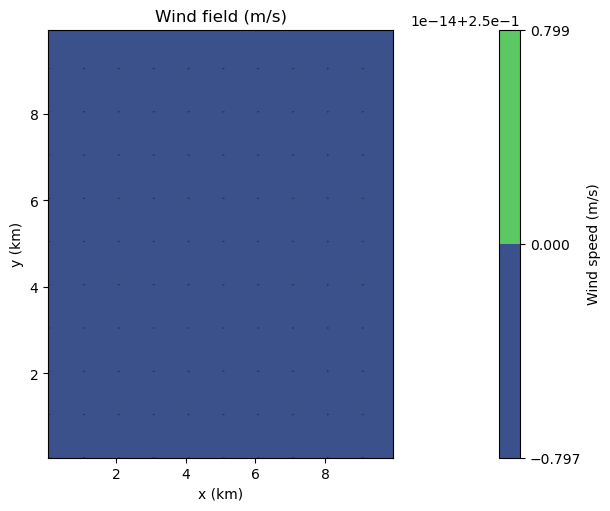

Saved: diffusivity_field_uniform_wind_uniform.png


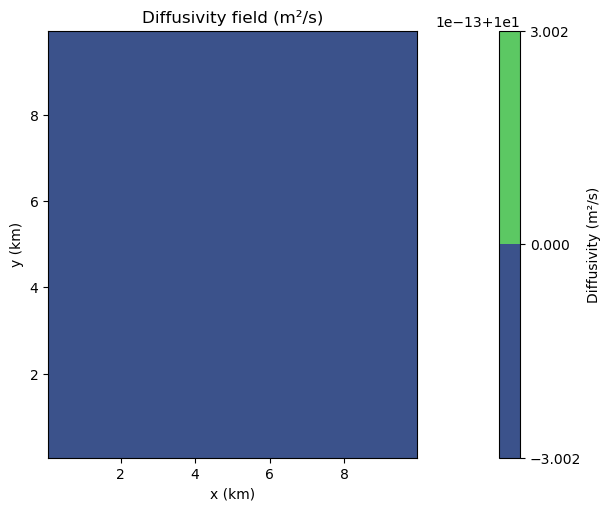

=== Stability diagnostics ===
  Courant number (x): 0.075  OK
  Courant number (y): 0.000  OK
  Diffusion number (x): 0.0300  OK
  Diffusion number (y): 0.0300  OK

Integration complete: 1200 steps, 600.0 minutes simulated.
Saved: snapshots_wind_uniform_diffu_uniform_source_gaussian_bc_dirichlet.png


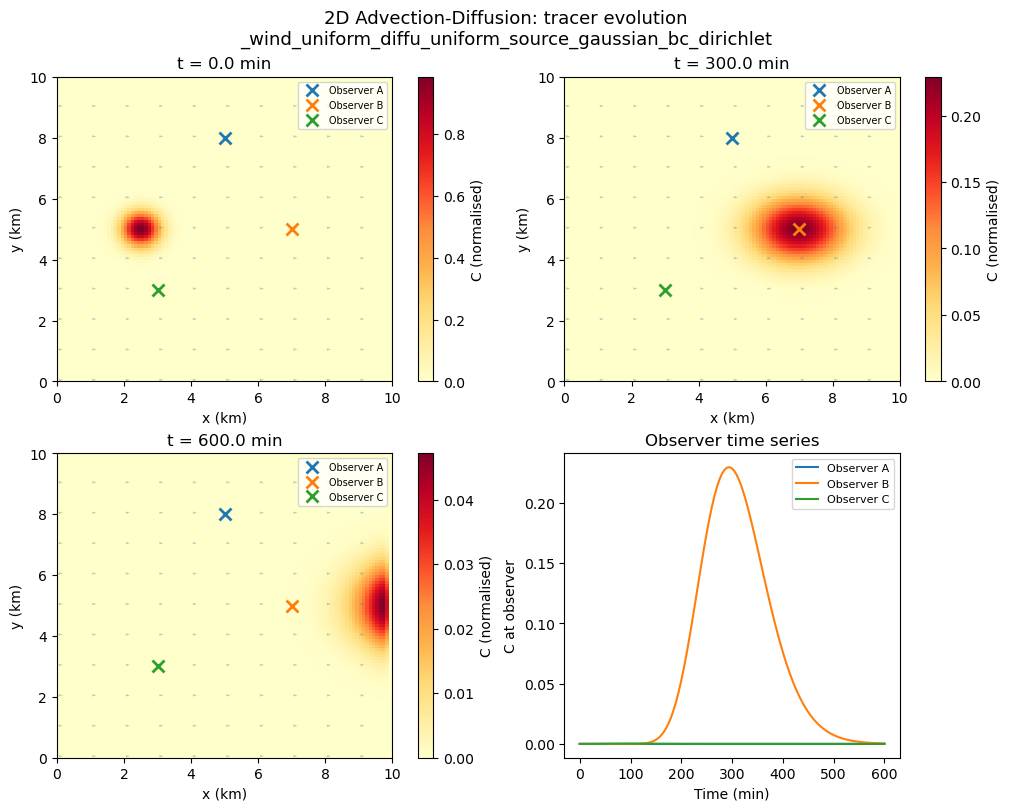

Saved: animation_wind_uniform_diffu_uniform_source_gaussian_bc_dirichlet.gif
DONE


In [14]:
wind_field = 'uniform'  # options are ['uniform', 'valley', 'circular']
diffusivity = 'uniform'  # options are ['uniform', 'half-half', 'turbulent']
source_type = 'gaussian'  # options are ['gaussian', 'fire']:
boundary_condition = 'dirichlet'  # options are ['dirichlet', 'periodic']:

run_simulation(wind_field, diffusivity, source_type, boundary_condition,
               show_plots=True, save_plots=True,
               save_animation=True,  # this takes some time, set to False to speed up things
               observers=None,
              )